### Import Required Libraries

In [2]:
import pandas as pd
import numpy as np


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import plotly.express as px
import plotly.graph_objects as go

In [5]:
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

### Load Processed Data

In [6]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum_history = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip_data = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category_data = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
folio_data = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
holdings_data = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

datasets = {'Fund Master':fund_master,
            'NAV History':nav_history,
            'AUM History':aum_history,
            'SIP Inflows':sip_data,
            'Category Inflows':category_data,
            'Folio Count':folio_data,
            'Portfolio Holdings':holdings_data}

for name, df in datasets.items():
    print('-'*50)
    print(name+' '+'Dataset')
    print('-'*50)
    print("Shape:",df.shape)
    print('\nColumns:\n',df.columns.tolist())
    print('\nFirst 5 rows:\n',df.head())
    print(f'\n{name} info:',df.info())
    print(f'\n{name} summary:\n',df.describe())
    print()
    

--------------------------------------------------
Fund Master Dataset
--------------------------------------------------
Shape: (40, 15)

Columns:
 ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

First 5 rows:
    amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14 

### NAV Trend Analysis

In [7]:
nav_hist2 = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [8]:
print(nav_hist2.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name']


In [9]:
nav_hist2=nav_hist2.sort_values(['scheme_name','date'])

In [10]:
#creating plotly line chart for NAV trend of mutual fund schemes
figure = px.line(
    nav_hist2,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme Name"
    }
)


In [11]:
#Highlighting 2023 BULL RUN in the plot
figure.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightblue",
    opacity=0.5,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

In [12]:
#Highlighting 2024 Market Correction in the plot
figure.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.5,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

plt.tight_layout()
figure.show()
figure.write_image('../EDA_charts/NAV_Trend_Analysis.png')
print("NAV Trend Analysis completed successfully.")

NAV Trend Analysis completed successfully.


<Figure size 640x480 with 0 Axes>

### Insights of NAV Trend Analysis

- The daily NAV trends indicate a steady long-term appreciation across most mutual fund schemes from 2022 to 2026.
- A strong upward movement is visible during 2023, reflecting a broad market bull run.
- Temporary declines during 2024 suggest a market correction before many schemes resumed their upward trajectory.
- Overall, the NAV trends demonstrate positive long-term growth across the mutual fund industry.

### AUM Growth Analysis

In [13]:
aum_history['date'] = pd.to_datetime(aum_history['date'])
aum_history['year'] = aum_history['date'].dt.year
print(aum_history['year'].unique())

[2022 2023 2024 2025]


In [14]:
aum_hist2  = aum_history[aum_history['year'].between(2022, 2025)]
print(aum_hist2['year'].unique())

[2022 2023 2024 2025]


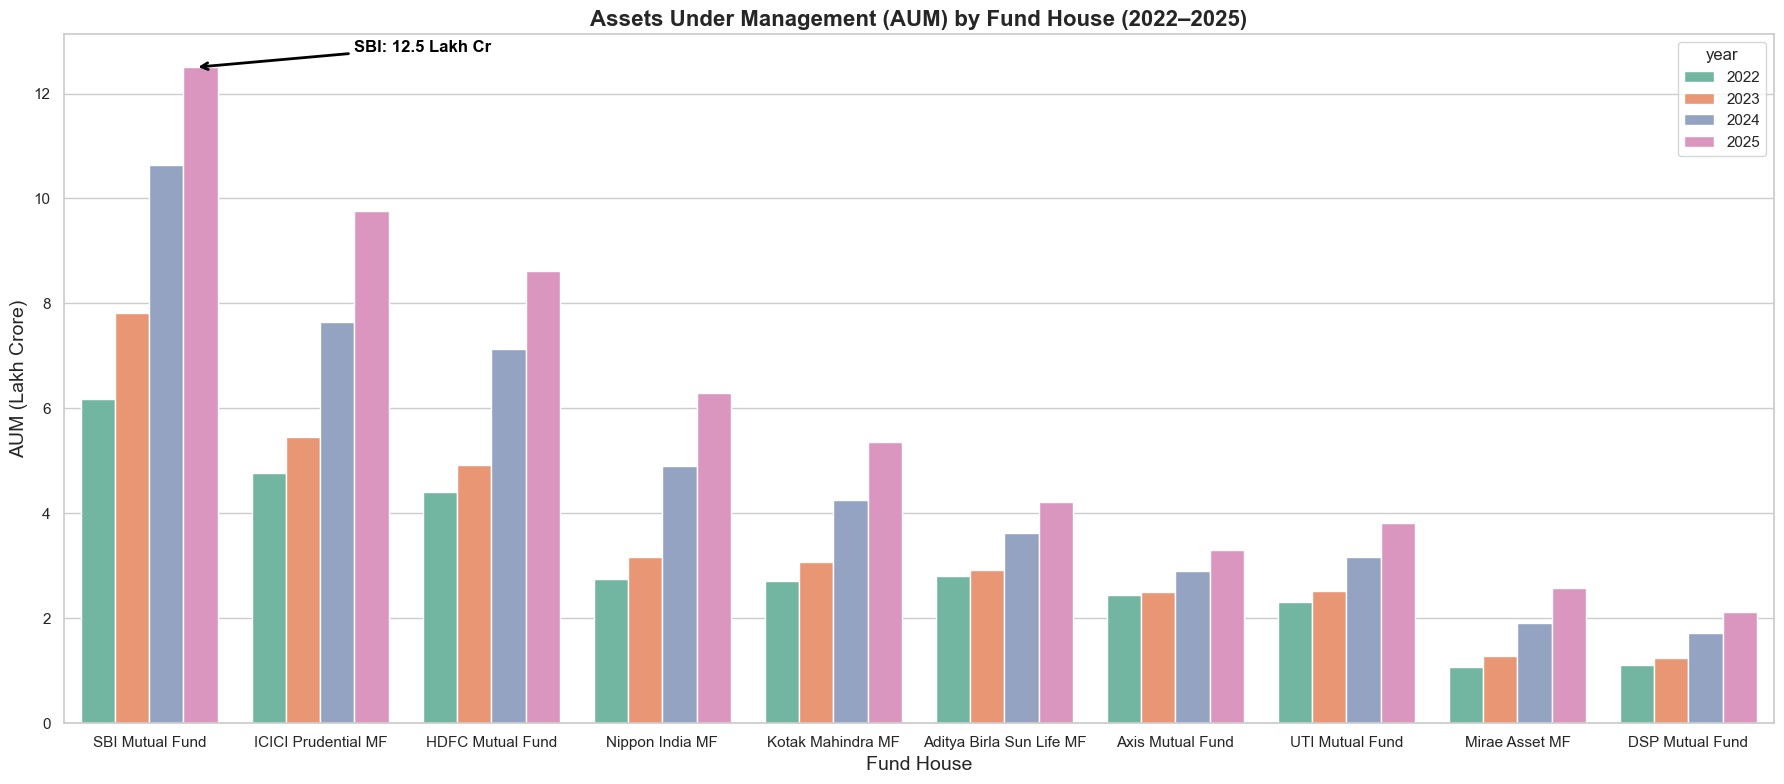

AUM by Fund House Analysis completed successfully.


<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(18, 8))
fig = sns.barplot(data=aum_hist2, 
                  x='fund_house', 
                  y='aum_lakh_crore', 
                  hue='year',
                  errorbar=None,
                  palette='Set2')
plt.title('Assets Under Management (AUM) by Fund House (2022–2025)',
          fontsize=16, fontweight='bold')

plt.xlabel('Fund House', fontsize=14)
plt.ylabel('AUM (Lakh Crore)', fontsize=14)
plt.tight_layout()

#Highlighting SBI at ₹12.5L Cr
plt.annotate(
    "SBI: 12.5 Lakh Cr",
    xy=(0.27, 12.5),          # Arrow points to SBI's 2025 bar
    xytext=(1.2, 12.8),    # Position of the annotation text
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=2
    ),
    fontsize=12,
    color="black",
    fontweight="bold"
)

plt.show()
plt.savefig('../EDA_charts/AUM_by_Fund_House.png')
print("AUM by Fund House Analysis completed successfully.")

### Insights of AUM Growth Analysis

- SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across all four years.
- Most fund houses exhibited steady AUM growth from 2022 to 2025, indicating increasing investor participation.
- SBI Mutual Fund reached approximately ₹12.5 lakh crore AUM in 2025, reinforcing its dominant market position.
- The overall upward trend in AUM reflects the expansion of the Indian mutual fund industry during the analysis period.

### SIP Inflow Time-Series

In [16]:
sip_data['month']=pd.to_datetime(sip_data['month'])
sip_data = sip_data.sort_values('month')

In [17]:
#Creating a line chart for SIP inflows trend
figure = px.line(sip_data,
                 x='month',
                 y='sip_inflow_crore',
                 title="Monthly SIP Inflows Trend (Jan 2022– Dec 2025)",
                 labels={
                     "month": "Month",
                     "sip_inflow_crore": "SIP Inflows (Crore)"},
                 markers=True,
                 )

#Maximum SIP inflow 
max_row = sip_data.loc[
    sip_data["sip_inflow_crore"].idxmax()]
print(f"Maximum SIP Inflow: {max_row['sip_inflow_crore']} Crore in {max_row['month'].strftime('%B %Y')}")

#Annotating the maximum SIP inflow point on the chart
figure.add_annotation(
    x=max_row['month'].strftime('%Y-%m'),
    y=max_row['sip_inflow_crore'],
    text=f"All-Time High: {max_row['sip_inflow_crore']} Crore",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="black",
)

figure.update_layout(
    title={
        'text': "Monthly SIP Inflows Trend (Jan 2022– Dec 2025)",
        'x':0.5,
        'xanchor': 'center'}
)

figure.show()
figure.write_image('../EDA_charts/SIP_Inflows_Trend.png')
print("SIP Inflows Trend Analysis completed successfully.")

Maximum SIP Inflow: 31002 Crore in December 2025


SIP Inflows Trend Analysis completed successfully.


### Insights of SIP Inflow Trend Analysis 

- Monthly SIP inflows exhibited a consistent upward trend from January 2022 to December 2025.
- Investor participation increased steadily over the four-year period.
- The highest monthly SIP inflow was recorded in December 2025, reaching approximately ₹31,002 crore.
- The sustained rise in SIP contributions reflects growing investor confidence in mutual fund investments.

### Category Inflow Heatmap

In [22]:
heatmap_df=category_data.copy()  #creating a copy of the category_data DataFrame for heatmap analysis

In [24]:
heatmap_df['month'] = pd.to_datetime(heatmap_df['month'])
heatmap_df["month"] = heatmap_df["month"].dt.strftime("%b-%Y")

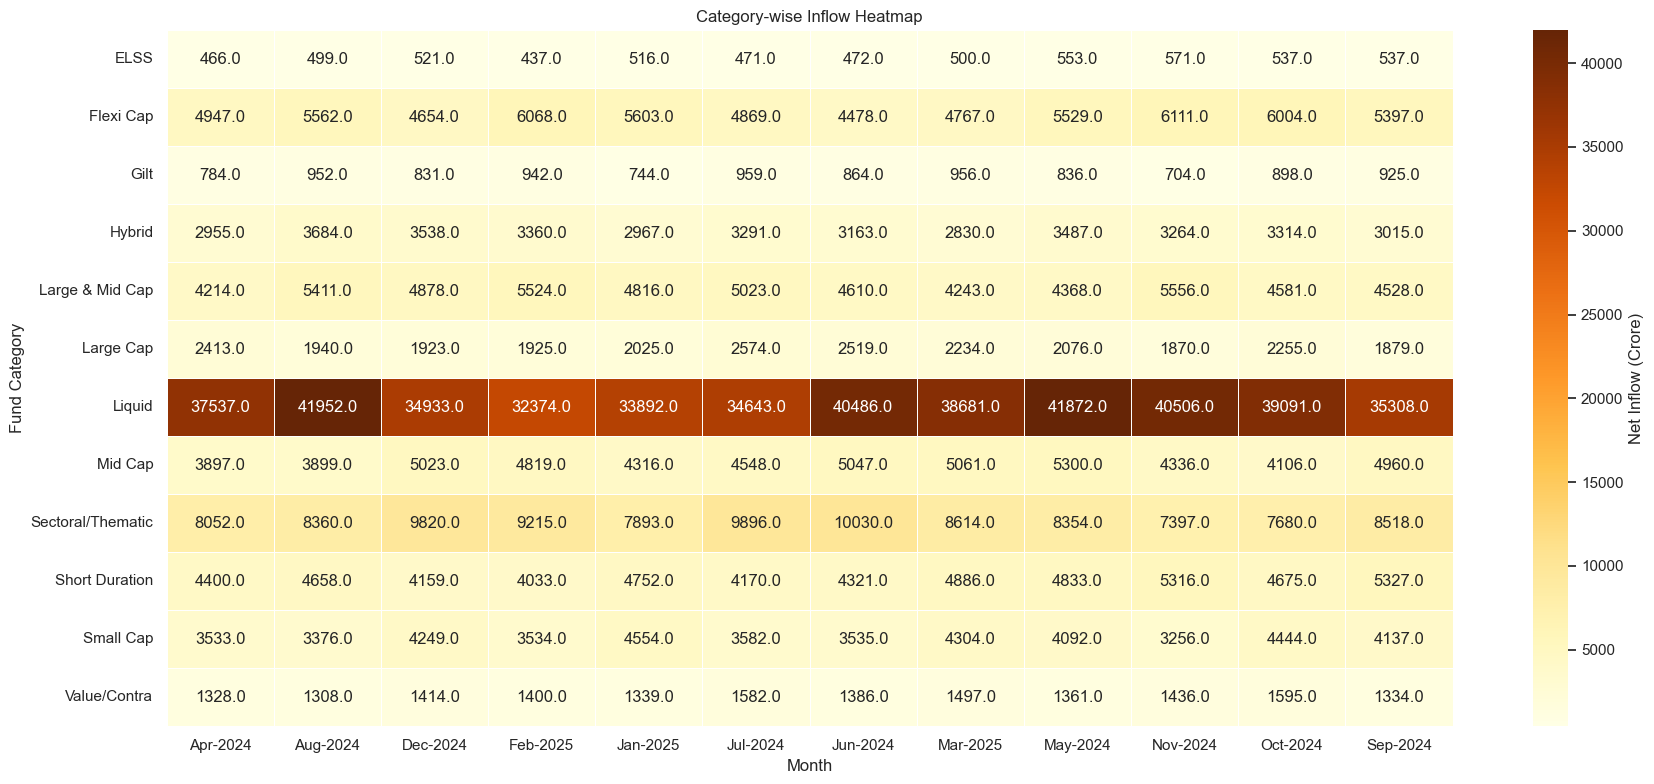

Category-wise Inflow Heatmap Analysis completed successfully.


In [25]:
#creating a pivot table for heatmap visualization
heatmap_pivot = heatmap_df.pivot(index='category', 
                                 columns='month', 
                                 values='net_inflow_crore')

#creating a heatmap for category inflows
plt.figure(figsize=(18, 8)) 
sns.heatmap(heatmap_pivot, annot=True, cmap="YlOrBr", linewidths=0.5, fmt=".1f", cbar_kws={'label': 'Net Inflow (Crore)'})
plt.title("Category-wise Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig('../EDA_charts/Category_Inflows_Heatmap.png')
plt.show()
print("Category-wise Inflow Heatmap Analysis completed successfully.")

### Insights of Category Flow Heatmap

- Equity-oriented categories such as Large Cap, Mid Cap, and Small Cap received consistently strong net inflows during the observed period.
- Investor preferences varied across months, with some categories experiencing noticeably higher inflows than others.
- The heatmap clearly highlights the concentration of investments across different mutual fund categories over time.

### Folio Count Growth Analysis

In [26]:
folio_df=folio_data.copy()  #creating a copy of the folio_data DataFrame for folio count analysis

In [27]:
folio_df['month'] = pd.to_datetime(folio_df['month'])
folio_df = folio_df.sort_values('month')

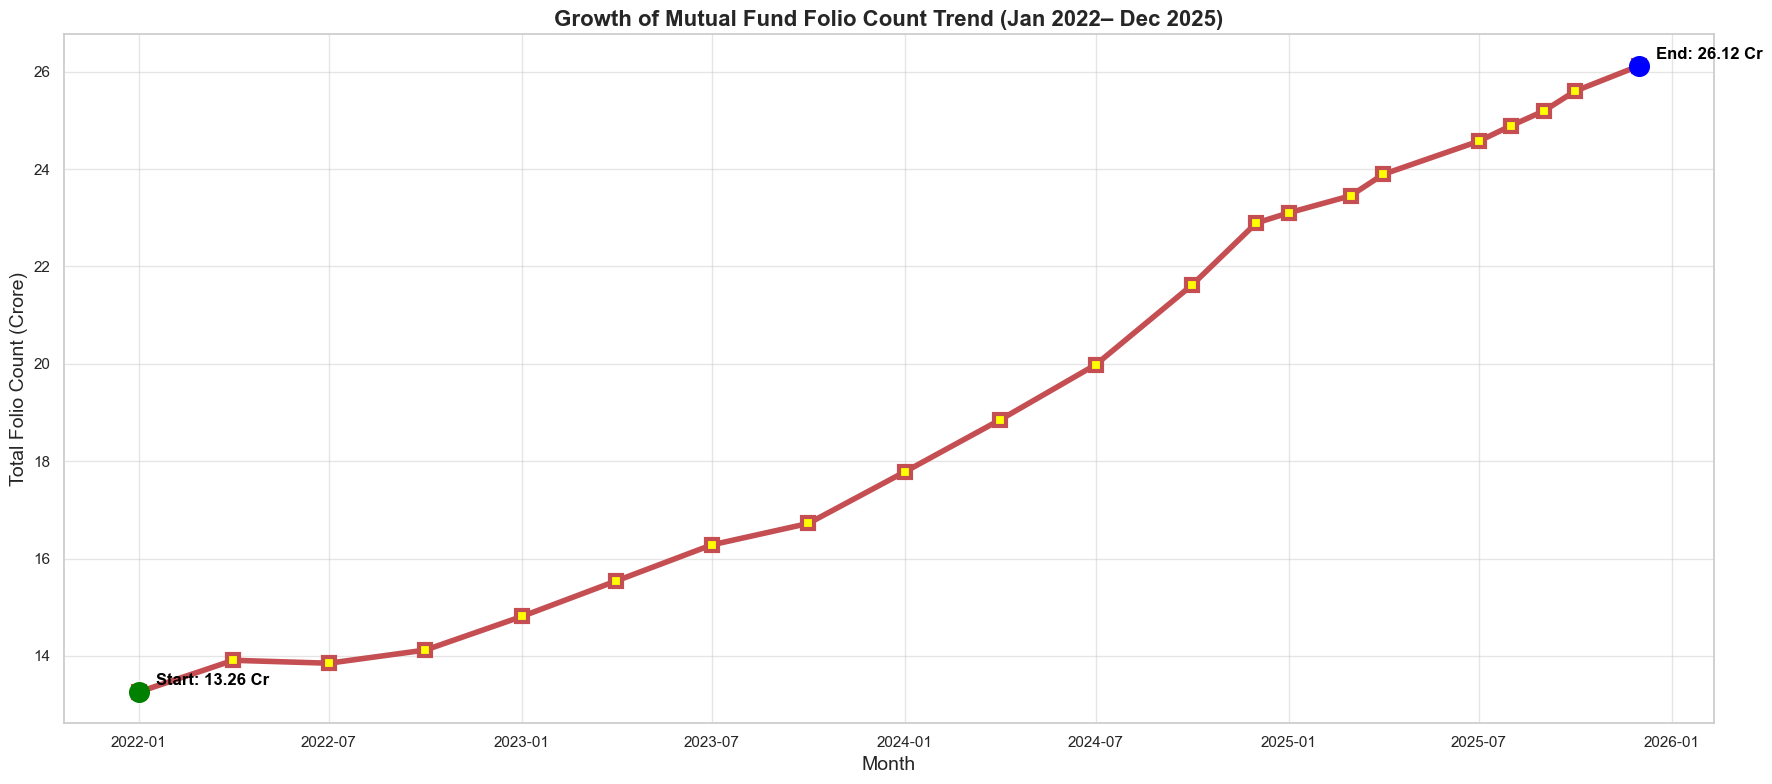

Folio Count Trend Analysis completed successfully.


In [28]:
#creating line chart for folio count trend
plt.figure(figsize=(18, 8))
plt.plot(folio_df['month'], 
         folio_df['total_folios_crore'],
         marker='s',
         markersize=8,
         markerfacecolor='yellow', 
         markeredgewidth=3,
         color='r',
         linewidth=4,)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Folio Count (Crore)', fontsize=14)
plt.title('Growth of Mutual Fund Folio Count Trend (Jan 2022– Dec 2025)', fontsize=16, fontweight='bold')

#starting and ending  points of the line
start = folio_df.iloc[0]
end = folio_df.iloc[-1]

#marking the starting point of the line
plt.scatter(start['month'],
            start['total_folios_crore'], 
            color='green', 
            s=200, 
            zorder=5)
plt.annotate(f"Start: {start['total_folios_crore']} Cr",
             (start['month'], start['total_folios_crore']),
             xytext=(12, 5),
             textcoords='offset points',
             fontsize=12,
             color='black',
             weight='bold')

#marking the ending point of the line
plt.scatter(end['month'],
            end['total_folios_crore'], 
            color='blue', 
            s=200, 
            zorder=5)   
plt.annotate(f"End: {end['total_folios_crore']} Cr",
             (end['month'], end['total_folios_crore']),
             xytext=(12, 5),
             textcoords='offset points',
             fontsize=12,
             color='black',
             weight='bold')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('../EDA_charts/Folio_Count_Trend.png')
plt.show() 
print("Folio Count Trend Analysis completed successfully.")

## Insights of Folio Count Growth Analysis

- The total mutual fund folio count showed a steady increase throughout the analysis period.
- The continuous upward trend reflects growing retail investor participation in mutual funds.
- The folio count nearly doubled over the observed period, indicating strong expansion of the mutual fund investor base.

### NAV Return Correlation Matrix

In [29]:
nav_df = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
nav_df['date'] = pd.to_datetime(nav_df['date'])
funds_selected = nav_df['scheme_name'].unique()[:10]  # Selecting the first 10 unique scheme names for analysis
nav_df = nav_df[nav_df['scheme_name'].isin(funds_selected)]

In [30]:
#creating a pivot table for heatmap visualization
nav_pivot = nav_df.pivot(index='date', columns='scheme_name', values='nav')

#calculating Daily Returns for the selected funds
daily_returns = nav_pivot.pct_change() # Daily Returns
correlation_matrix = daily_returns.corr() # Correlation Matrix

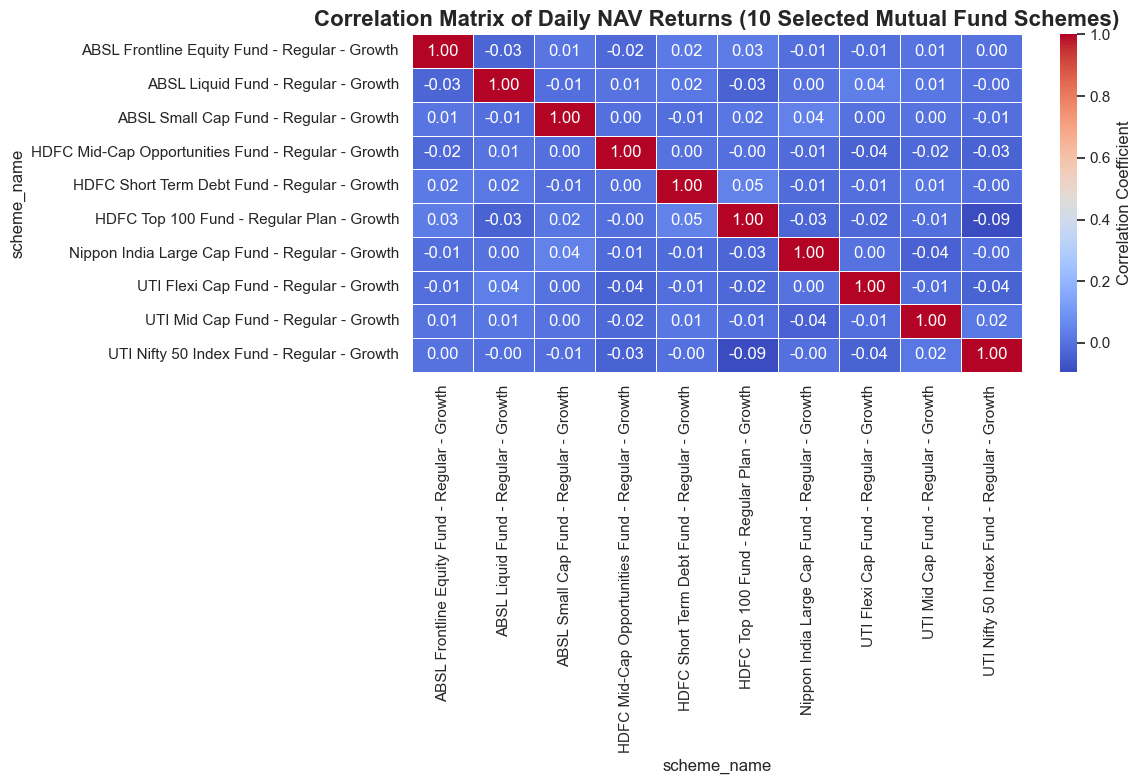

Correlation Matrix of Daily NAV Returns Analysis completed successfully.


In [31]:
#plotting the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Daily NAV Returns (10 Selected Mutual Fund Schemes)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../EDA_charts/Daily_NAV_Returns_Correlation_Heatmap.png')
plt.show()
print("Correlation Matrix of Daily NAV Returns Analysis completed successfully.")

## Insights of NAV Return Correlation Matrix

- Most equity mutual funds exhibit positive correlations, indicating similar responses to overall market movements.
- A correlation value close to 1 suggests that two funds move together, while lower values indicate greater diversification potential.
- The correlation matrix helps identify funds with similar or contrasting return patterns.

### Sector Allocation Donut

In [32]:
#creating a copy of the holdings_data DataFrame for analysis
holdings_df = holdings_data.copy()

In [33]:
#Aggregating sector weights
sector_weights = (holdings_df.groupby(['sector'])['weight_pct'].sum().sort_values(ascending=False))
print("Aggregated Sector Weights:\n", sector_weights)

Aggregated Sector Weights:
 sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


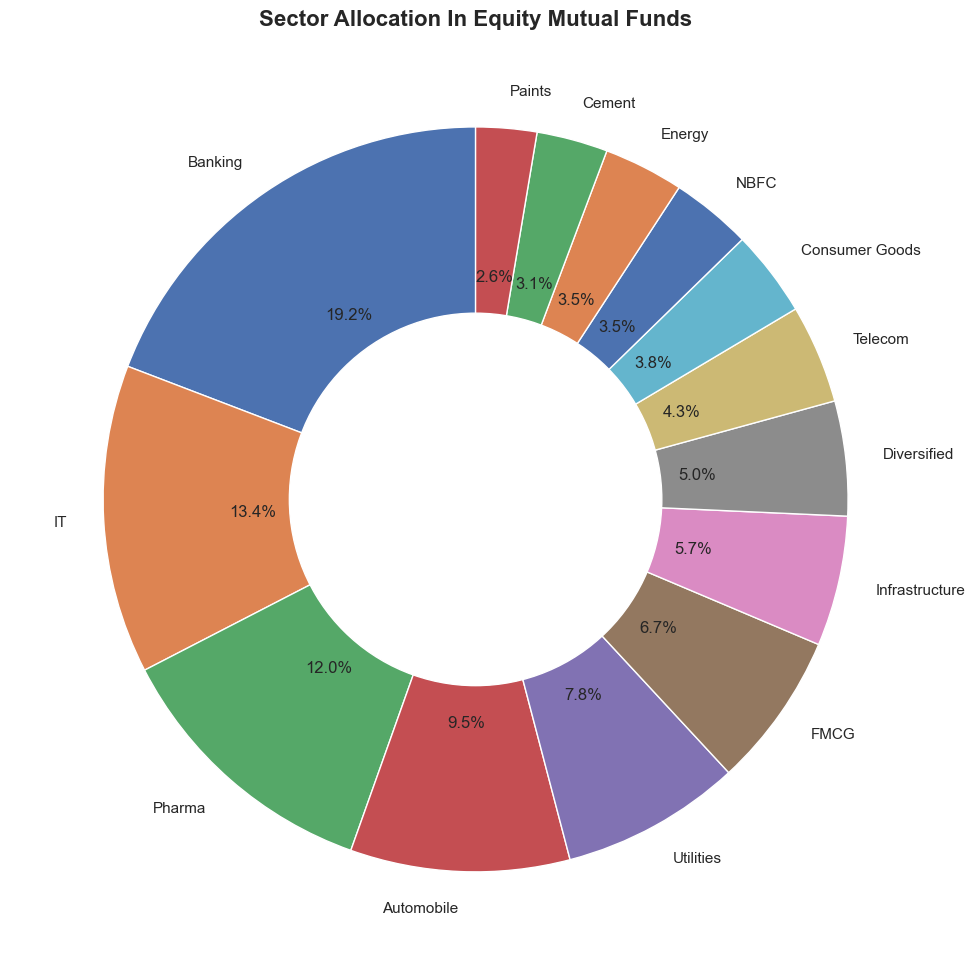

Sector Allocation In Equity Mutual Funds Analysis completed successfully.


In [34]:
#plotting Donut chart for sector weights
plt.figure(figsize=(10, 10))

#creating a pie chart for sector weights
plt.pie(sector_weights,
        labels=sector_weights.index,
        autopct='%1.1f%%', 
        startangle=90)

#creating a circle at the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation In Equity Mutual Funds", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../EDA_charts/Sector_Allocation_Donut_Chart.png')
plt.show()
print("Sector Allocation In Equity Mutual Funds Analysis completed successfully.")

## Insights of Sector Allocation Donut

- Financial Services accounted for the largest share of the aggregated portfolio allocation.
- Information Technology, Healthcare, and Automobile sectors also represented significant allocations.
- The sector distribution indicates diversification across multiple industries while maintaining stronger exposure to major sectors.